# Random Forest from Scratch
Visualizing the power of ensemble learning. We compare a single Decision Tree against a Random Forest to see how 'Bagging' smooths out the decision boundary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from random_forest_classifier import MyRandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

## 1. Load Non-Linear Data (Moons)
We use the Moons dataset because it requires a non-linear boundary.

In [2]:
X, y = datasets.make_moons(n_samples=200, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train Models
1. A single Decision Tree (prone to overfitting/high variance).
2. A Random Forest (reduces variance by averaging).

In [3]:
# Single Tree (Sklearn for baseline comparison)
tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(X_train, y_train)

# Custom Random Forest (5 trees)
forest_5 = MyRandomForestClassifier(n_estimators=5, max_depth=5, random_state=42)
forest_5.fit(X_train, y_train)

# Custom Random Forest (20 trees)
forest_20 = MyRandomForestClassifier(n_estimators=20, max_depth=5, random_state=42)
forest_20.fit(X_train, y_train)

print(f"Tree Acc: {tree.score(X_test, y_test):.4f}")
print(f"Forest (5) Acc: {forest_5.score(X_test, y_test):.4f}")
print(f"Forest (20) Acc: {forest_20.score(X_test, y_test):.4f}")

Tree Acc: 0.9000
Forest (5) Acc: 0.8750
Forest (20) Acc: 0.9000


## 3. Visualize Decision Boundaries
Notice how the single tree creates jagged, boxy regions (overfitting noise). The Random Forest boundary is smoother and more robust.

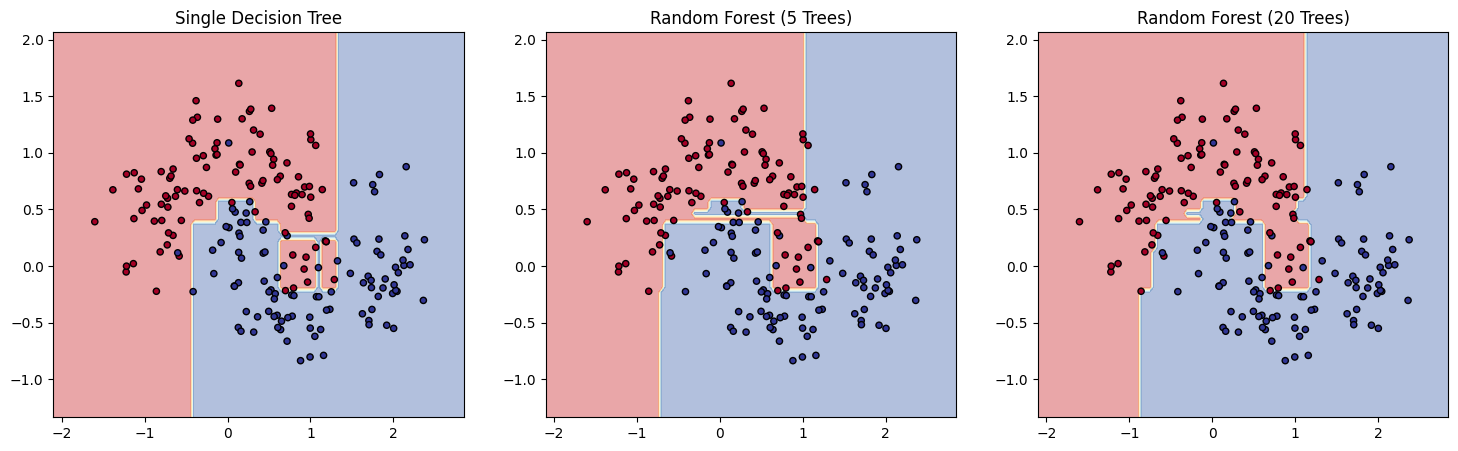

In [4]:
def plot_boundary(model, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_boundary(tree, "Single Decision Tree", axes[0])
plot_boundary(forest_5, "Random Forest (5 Trees)", axes[1])
plot_boundary(forest_20, "Random Forest (20 Trees)", axes[2])

plt.show()